# Viral Infection PDE Model with IFN Dynamics

This notebook implements the spatiotemporal PDE model of viral infection with interferon (IFN) signaling.

## Model Variables
| Variable | Description |
|----------|-------------|
| T | Target (uninfected) cells |
| E₁, E₂ | Eclipse-phase infected cells (two-stage) |
| I | Productively infected cells |
| V | Virus concentration (diffusible) |
| F | IFN concentration (diffusible) |

## PDEs
$$\frac{\partial T}{\partial t} = -\beta T V \left(\frac{k_{IF}}{k_{IF}+F}\right)$$
$$\frac{\partial E_1}{\partial t} = \beta T V \left(\frac{k_{IF}}{k_{IF}+F}\right) - k_E E_1$$
$$\frac{\partial E_2}{\partial t} = k_E E_1 - k_E E_2$$
$$\frac{\partial I}{\partial t} = k_E E_2 - \delta_I I$$
$$\frac{\partial V}{\partial t} = \nabla\cdot(D_V \nabla V) + p_V I\left(\frac{k_{PV}}{k_{PV}+F}\right) - c_V V - \delta_{FV}\left(\frac{F}{F+k_{FV}}\right)FV$$
$$\frac{\partial F}{\partial t} = \nabla\cdot(D_F \nabla F) + p_F I\left(1 + a_F \frac{F^2}{K_F^2+F^2}\right) - c_F F$$

## 1. Imports and Setup

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.animation import FuncAnimation
from scipy.ndimage import laplace
from IPython.display import HTML
import warnings
warnings.filterwarnings('ignore')

## 2. Model Parameters
Using fitted values from the paper. Modify these to explore different regimes.

In [3]:
params = {
    # --- Infection & cell dynamics ---
    'beta':    8.0e-2,       # Infection rate (fitted)
    'k_E':     3.177313,     # Eclipse progression rate
    'delta_I': 1.633914,     # Infected cell death rate

    # --- Virus ---
    'p_V':     8.045948e1,   # Viral production rate
    'c_V':     7.091680,     # Viral clearance rate
    'D_V':     1.696999e-5,  # Viral diffusion coefficient

    # --- IFN (F) ---
    'p_F':     1.877042e-2,  # Base IFN production rate
    'c_F':     1.0e-1,       # IFN decay rate
    'D_F':     1.0e-2,       # IFN diffusion coefficient
    'a_F':     9.057379e3,   # IFN autocatalytic feedback strength
    'K_F':     4.066479e1,   # IFN feedback threshold

    # --- IFN mechanisms ---
    'k_IF':    2.840804e-1,  # IFN blocks infection (half-sat)
    'k_PV':    1.0e12,       # IFN blocks viral production (null: very large)
    'delta_FV':1.0e-12,      # IFN-driven viral clearance (null: ~0)
    'k_FV':    7.976671e1,   # IFN clearance half-sat scale
}

print('Parameters set:')
for k, v in params.items():
    print(f'  {k:12s} = {v:.4g}')

Parameters set:
  beta         = 0.08
  k_E          = 3.177
  delta_I      = 1.634
  p_V          = 80.46
  c_V          = 7.092
  D_V          = 1.697e-05
  p_F          = 0.01877
  c_F          = 0.1
  D_F          = 0.01
  a_F          = 9057
  K_F          = 40.66
  k_IF         = 0.2841
  k_PV         = 1e+12
  delta_FV     = 1e-12
  k_FV         = 79.77


## 3. Grid and Initial Conditions

In [4]:
# ── Spatial grid ──────────────────────────────────────────────────────────────
L  = 1.0          # Domain side length (arbitrary units)
N  = 100          # Grid points per side
dx = L / N        # Grid spacing
x  = np.linspace(0, L, N)
XX, YY = np.meshgrid(x, x)

# ── Time integration ──────────────────────────────────────────────────────────
T_end  = 10.0     # Total simulation time (days)
dt     = 1e-3     # Time step
n_steps = int(T_end / dt)
save_every = 200  # Save a snapshot every N steps

# ── Initial conditions ────────────────────────────────────────────────────────
T0  = np.ones((N, N))          # Uniform target cells
E1_0 = np.zeros((N, N))
E2_0 = np.zeros((N, N))
I0  = np.zeros((N, N))
F0  = np.zeros((N, N))

# Seed virus at centre
V0  = np.zeros((N, N))
cx, cy = N//2, N//2
r_seed = 5  # Seed radius in grid points
for i in range(N):
    for j in range(N):
        if (i-cx)**2 + (j-cy)**2 <= r_seed**2:
            V0[i, j] = 10.0

print(f'Grid: {N}x{N}, dx={dx:.4f}')
print(f'Time: 0 to {T_end} days, dt={dt}, steps={n_steps}')
print(f'Initial virus seed: radius={r_seed} grid pts, peak V={V0.max()}')

Grid: 100x100, dx=0.0100
Time: 0 to 10.0 days, dt=0.001, steps=10000
Initial virus seed: radius=5 grid pts, peak V=10.0


## 4. Laplacian Helper (Neumann BCs)

In [5]:
def laplacian_2d(u, dx):
    """5-point Laplacian with zero-flux (Neumann) boundary conditions."""
    lap = np.zeros_like(u)
    # Interior
    lap[1:-1, 1:-1] = (
        u[2:,  1:-1] + u[:-2, 1:-1] +
        u[1:-1, 2: ] + u[1:-1, :-2] -
        4 * u[1:-1, 1:-1]
    ) / dx**2
    # Boundaries (ghost-cell Neumann: reflect)
    lap[0,  :] = lap[1,  :]
    lap[-1, :] = lap[-2, :]
    lap[:,  0] = lap[:,  1]
    lap[:, -1] = lap[:, -2]
    return lap

print('Laplacian function defined (Neumann BCs).')

Laplacian function defined (Neumann BCs).


## 5. RHS (Right-Hand Side) Functions

In [6]:
def rhs(T, E1, E2, I, V, F, p, dx):
    """
    Compute time derivatives for all state variables.
    p : parameter dict
    """
    # ── Pre-compute shared terms ──────────────────────────────────────────────
    IFN_block_inf = p['k_IF'] / (p['k_IF'] + F)          # IFN blocks infection
    IFN_block_prod = p['k_PV'] / (p['k_PV'] + F)         # IFN blocks viral prod
    IFN_clear_V = (F / (F + p['k_FV'])) * F              # IFN clears virus
    IFN_feedback = 1.0 + p['a_F'] * F**2 / (p['K_F']**2 + F**2)  # autocatalytic

    infection_flux = p['beta'] * T * V * IFN_block_inf

    # ── ODEs (cells – no spatial diffusion) ──────────────────────────────────
    dT  = -infection_flux
    dE1 =  infection_flux  - p['k_E'] * E1
    dE2 =  p['k_E'] * E1  - p['k_E'] * E2
    dI  =  p['k_E'] * E2  - p['delta_I'] * I

    # ── PDEs (diffusible species) ─────────────────────────────────────────────
    dV = (p['D_V'] * laplacian_2d(V, dx)
          + p['p_V'] * I * IFN_block_prod
          - p['c_V'] * V
          - p['delta_FV'] * IFN_clear_V * V)

    dF = (p['D_F'] * laplacian_2d(F, dx)
          + p['p_F'] * I * IFN_feedback
          - p['c_F'] * F)

    return dT, dE1, dE2, dI, dV, dF

print('RHS function defined.')

RHS function defined.


## 6. Time Integration (Forward Euler)

> **Tip:** For production use, replace Forward Euler with an implicit or operator-split scheme (e.g., Crank-Nicolson for diffusion + explicit for reactions) to allow larger, stable time steps.

In [7]:
# ── Stability check (diffusion CFL) ──────────────────────────────────────────
D_max   = max(params['D_V'], params['D_F'])
dt_CFL  = dx**2 / (4 * D_max)
print(f'Diffusion CFL limit: dt < {dt_CFL:.5f}  (using dt={dt})')
assert dt <= dt_CFL, f'dt={dt} exceeds CFL limit {dt_CFL:.5f} – reduce dt!'

# ── Allocate state ────────────────────────────────────────────────────────────
T_  = T0.copy()
E1_ = E1_0.copy()
E2_ = E2_0.copy()
I_  = I0.copy()
V_  = V0.copy()
F_  = F0.copy()

# ── Storage for snapshots ─────────────────────────────────────────────────────
snaps_V, snaps_F, snaps_I, snaps_T = [], [], [], []
snap_times = []

def save_snap(t):
    snaps_V.append(V_.copy())
    snaps_F.append(F_.copy())
    snaps_I.append(I_.copy())
    snaps_T.append(T_.copy())
    snap_times.append(t)

save_snap(0.0)   # t=0 snapshot

# ── Main loop ─────────────────────────────────────────────────────────────────
print(f'Running {n_steps} steps ...')
for step in range(1, n_steps + 1):
    dT, dE1, dE2, dI, dV, dF = rhs(T_, E1_, E2_, I_, V_, F_, params, dx)

    T_  = np.clip(T_  + dt * dT,  0, None)
    E1_ = np.clip(E1_ + dt * dE1, 0, None)
    E2_ = np.clip(E2_ + dt * dE2, 0, None)
    I_  = np.clip(I_  + dt * dI,  0, None)
    V_  = np.clip(V_  + dt * dV,  0, None)
    F_  = np.clip(F_  + dt * dF,  0, None)

    if step % save_every == 0:
        t_now = step * dt
        save_snap(t_now)
        if step % (save_every * 20) == 0:
            print(f'  t={t_now:.2f}  V_max={V_.max():.3g}  F_max={F_.max():.3g}  '
                  f'I_max={I_.max():.3g}  T_mean={T_.mean():.3f}')

print(f'Done. Saved {len(snap_times)} snapshots.')

Diffusion CFL limit: dt < 0.00250  (using dt=0.001)
Running 10000 steps ...
  t=4.00  V_max=0.138  F_max=8.66e-05  I_max=0.0113  T_mean=0.999
  t=8.00  V_max=0.0179  F_max=2.51e-05  I_max=0.00146  T_mean=0.998
Done. Saved 51 snapshots.


## 7. Spatial Snapshots

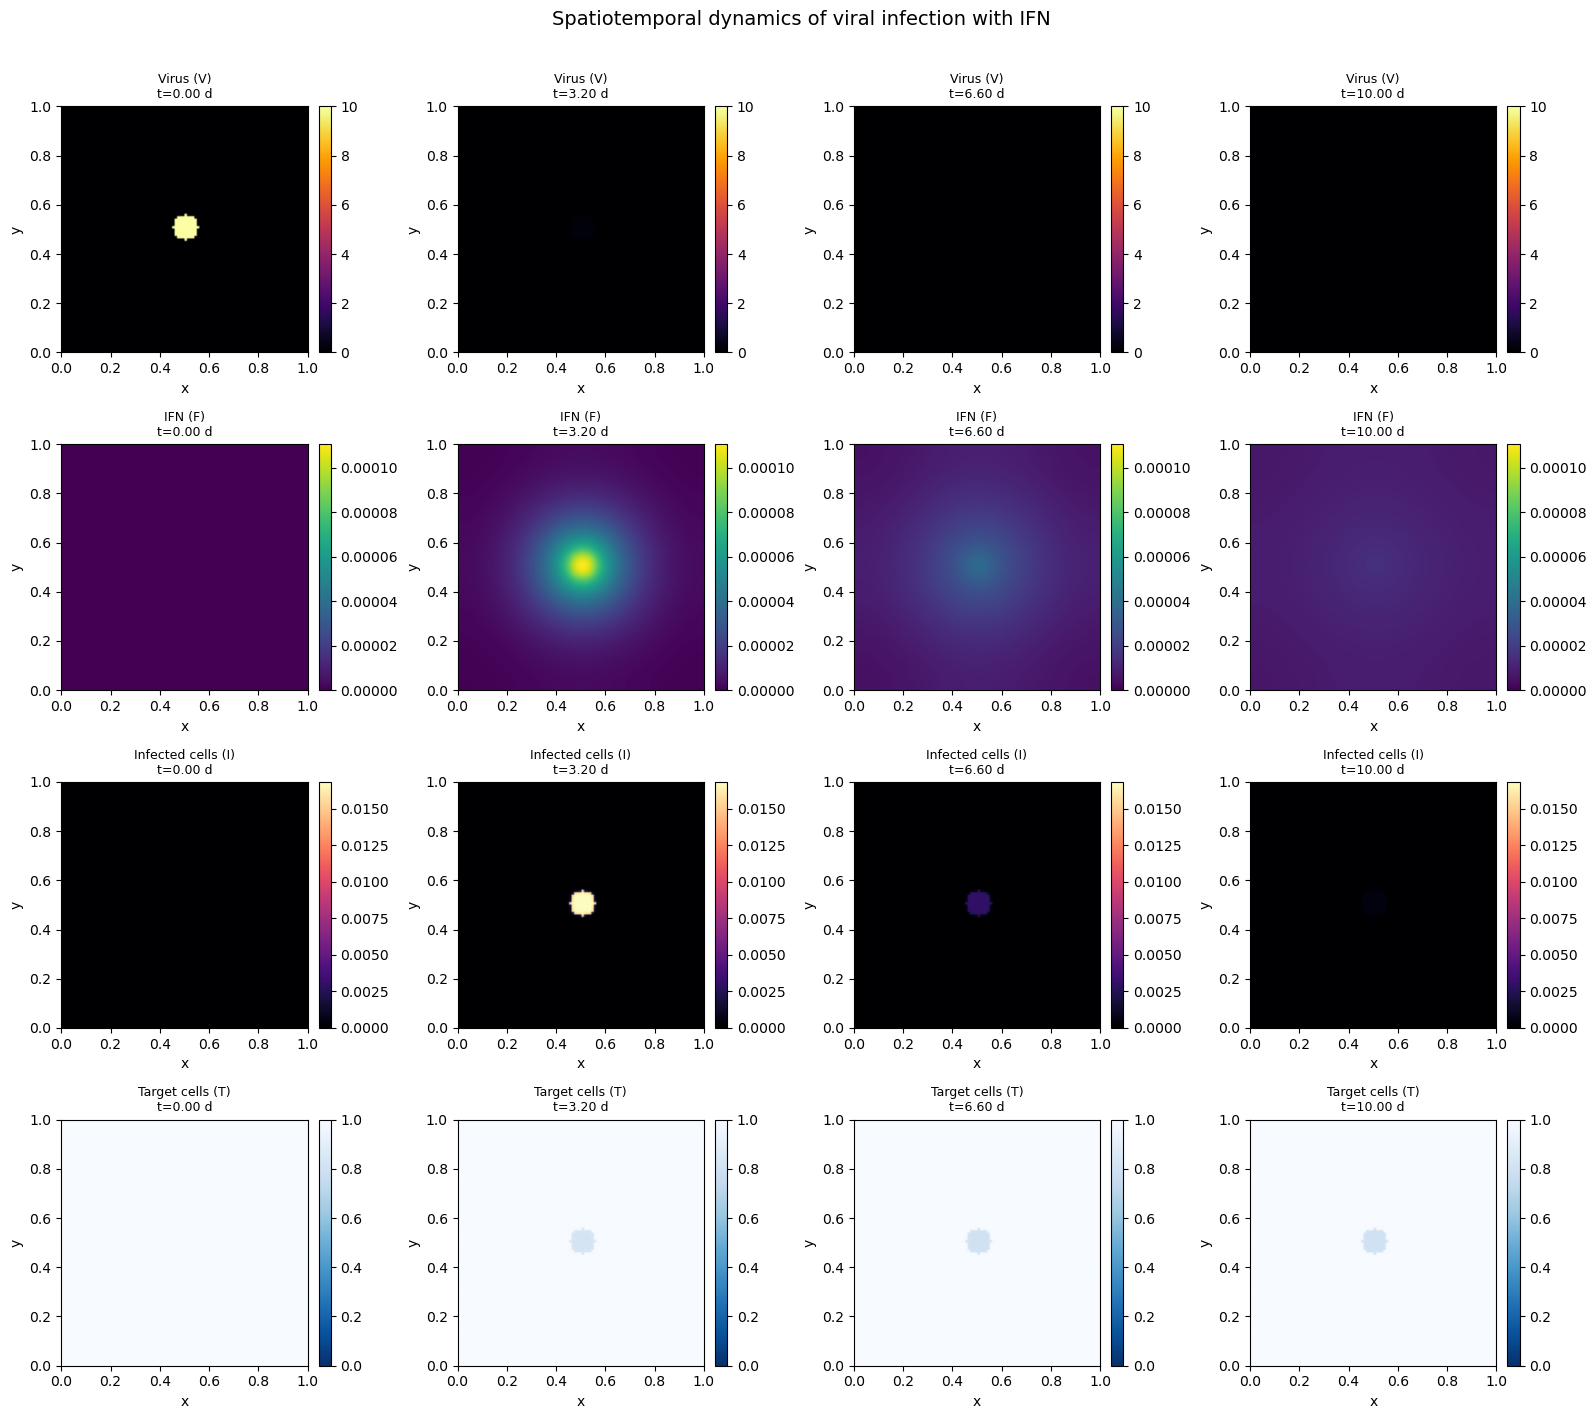

In [8]:
# Choose 4 evenly spaced time points to display
idx_show = np.linspace(0, len(snap_times)-1, 4, dtype=int)

fig, axes = plt.subplots(4, 4, figsize=(16, 14))
titles_rows = ['Virus (V)', 'IFN (F)', 'Infected cells (I)', 'Target cells (T)']
data_rows   = [snaps_V,     snaps_F,   snaps_I,              snaps_T]
cmaps       = ['inferno',   'viridis',  'magma',              'Blues_r']

for row, (title, data, cmap) in enumerate(zip(titles_rows, data_rows, cmaps)):
    vmax = max(d.max() for d in [data[i] for i in idx_show]) + 1e-12
    for col, idx in enumerate(idx_show):
        ax = axes[row, col]
        im = ax.imshow(data[idx], origin='lower', cmap=cmap,
                       vmin=0, vmax=vmax, extent=[0, L, 0, L])
        ax.set_title(f'{title}\nt={snap_times[idx]:.2f} d', fontsize=9)
        ax.set_xlabel('x'); ax.set_ylabel('y')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle('Spatiotemporal dynamics of viral infection with IFN', fontsize=14, y=1.01)
plt.tight_layout()
# plt.savefig('spatial_snapshots.png', dpi=120, bbox_inches='tight')
plt.show()
# print('Saved → spatial_snapshots.png')

## 8. Spatial-Mean Time Series

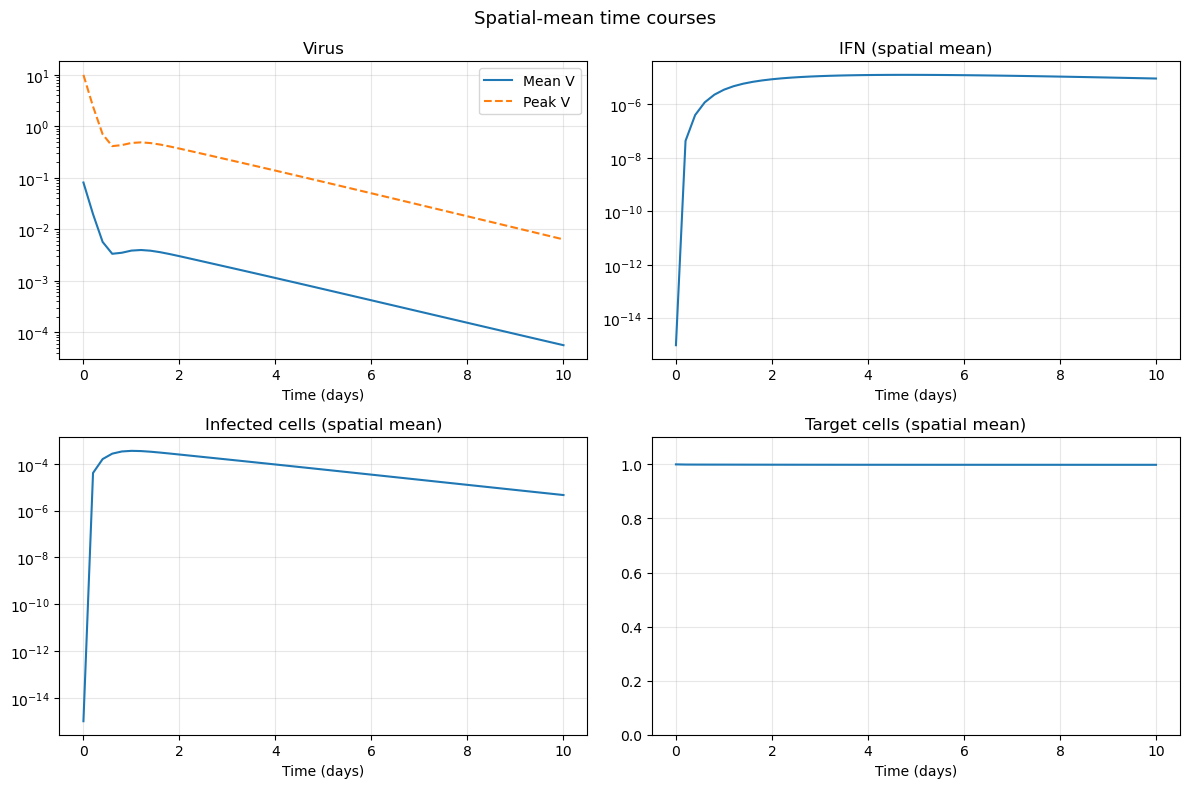

In [9]:
times = np.array(snap_times)
V_mean = np.array([s.mean() for s in snaps_V])
F_mean = np.array([s.mean() for s in snaps_F])
I_mean = np.array([s.mean() for s in snaps_I])
T_mean = np.array([s.mean() for s in snaps_T])
V_peak = np.array([s.max()  for s in snaps_V])

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0,0].semilogy(times, V_mean + 1e-15, label='Mean V')
axes[0,0].semilogy(times, V_peak + 1e-15, label='Peak V', ls='--')
axes[0,0].set_title('Virus'); axes[0,0].set_xlabel('Time (days)')
axes[0,0].legend()

axes[0,1].semilogy(times, F_mean + 1e-15)
axes[0,1].set_title('IFN (spatial mean)'); axes[0,1].set_xlabel('Time (days)')

axes[1,0].semilogy(times, I_mean + 1e-15)
axes[1,0].set_title('Infected cells (spatial mean)'); axes[1,0].set_xlabel('Time (days)')

axes[1,1].plot(times, T_mean)
axes[1,1].set_title('Target cells (spatial mean)'); axes[1,1].set_xlabel('Time (days)')
axes[1,1].set_ylim([0, 1.1])

for ax in axes.flat:
    ax.grid(True, alpha=0.3)
plt.suptitle('Spatial-mean time courses', fontsize=13)
plt.tight_layout()
# plt.savefig('time_series.png', dpi=120)
plt.show()
# print('Saved → time_series.png')

## 9. Radial Profile Analysis (Spreading wavefront)

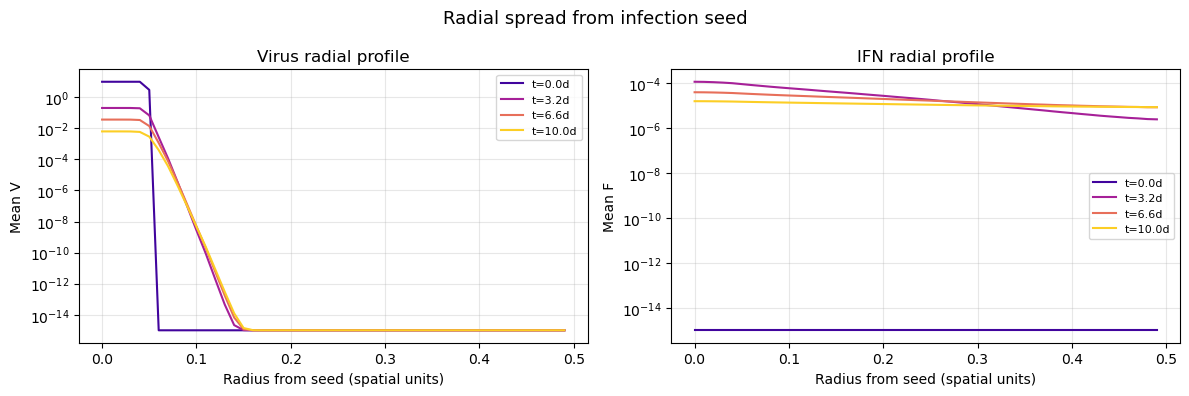

In [10]:
def radial_profile(field, cx=None, cy=None):
    """Compute azimuthally-averaged radial profile from centre."""
    if cx is None: cx = field.shape[0]//2
    if cy is None: cy = field.shape[1]//2
    y_idx, x_idx = np.ogrid[:field.shape[0], :field.shape[1]]
    r = np.sqrt((x_idx - cx)**2 + (y_idx - cy)**2).astype(int)
    r_max = min(cx, cy)
    radii  = np.arange(0, r_max)
    profile = np.array([field[r == ri].mean() if (r == ri).any() else 0
                        for ri in radii])
    return radii * dx, profile   # return physical radius

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(idx_show)))
for col_idx, snap_idx in enumerate(idx_show):
    t_label = f't={snap_times[snap_idx]:.1f}d'
    r, prof_V = radial_profile(snaps_V[snap_idx])
    r, prof_F = radial_profile(snaps_F[snap_idx])
    axes[0].semilogy(r, prof_V + 1e-15, color=colors[col_idx], label=t_label)
    axes[1].semilogy(r, prof_F + 1e-15, color=colors[col_idx], label=t_label)

axes[0].set_xlabel('Radius from seed (spatial units)')
axes[0].set_ylabel('Mean V'); axes[0].set_title('Virus radial profile')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

axes[1].set_xlabel('Radius from seed (spatial units)')
axes[1].set_ylabel('Mean F'); axes[1].set_title('IFN radial profile')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

plt.suptitle('Radial spread from infection seed', fontsize=13)
plt.tight_layout()
# plt.savefig('radial_profiles.png', dpi=120)
plt.show()

## 10. IFN Mechanism Comparison
Run the model with each IFN mechanism **individually nulled out** to isolate their contribution.

In [11]:
def run_mean_timeseries(params_override, T_end=10.0, dt=1e-3, N=60, L=1.0,
                        save_every=200):
    """Run the model and return spatial-mean time courses."""
    import copy
    p = copy.deepcopy(params)
    p.update(params_override)

    dx = L / N
    n_steps = int(T_end / dt)

    T_  = np.ones((N, N))
    E1_ = np.zeros((N, N))
    E2_ = np.zeros((N, N))
    I_  = np.zeros((N, N))
    V_  = np.zeros((N, N))
    F_  = np.zeros((N, N))
    cx = cy = N//2
    for i in range(N):
        for j in range(N):
            if (i-cx)**2+(j-cy)**2 <= (N//20)**2:
                V_[i,j] = 10.0

    times, V_mean, I_mean, T_mean = [0.0], [V_.mean()], [I_.mean()], [T_.mean()]

    for step in range(1, n_steps+1):
        dT, dE1, dE2, dI, dV, dF = rhs(T_, E1_, E2_, I_, V_, F_, p, dx)
        T_  = np.clip(T_  + dt*dT,  0, None)
        E1_ = np.clip(E1_ + dt*dE1, 0, None)
        E2_ = np.clip(E2_ + dt*dE2, 0, None)
        I_  = np.clip(I_  + dt*dI,  0, None)
        V_  = np.clip(V_  + dt*dV,  0, None)
        F_  = np.clip(F_  + dt*dF,  0, None)
        if step % save_every == 0:
            times.append(step*dt)
            V_mean.append(V_.mean())
            I_mean.append(I_.mean())
            T_mean.append(T_.mean())
    return np.array(times), np.array(V_mean), np.array(I_mean), np.array(T_mean)


scenarios = {
    'Full model':              {},
    'No IFN→infection block':  {'k_IF':  1e12},          # k_IF → ∞ (null)
    'No IFN→viral prod block': {'k_PV':  1e12},          # k_PV → ∞ already default
    'No IFN feedback':         {'a_F':   0},             # a_F = 0 (null)
    'No IFN→viral clearance':  {'delta_FV': 0},          # δ_FV = 0 (null)
    'No IFN at all':           {'p_F':   0},             # p_F = 0 kills IFN
}

results = {}
for name, override in scenarios.items():
    print(f'Running: {name} ...')
    results[name] = run_mean_timeseries(override, T_end=10.0, dt=1e-3, N=60)
print('All scenarios done.')

Running: Full model ...
Running: No IFN→infection block ...
Running: No IFN→viral prod block ...
Running: No IFN feedback ...
Running: No IFN→viral clearance ...
Running: No IFN at all ...
All scenarios done.


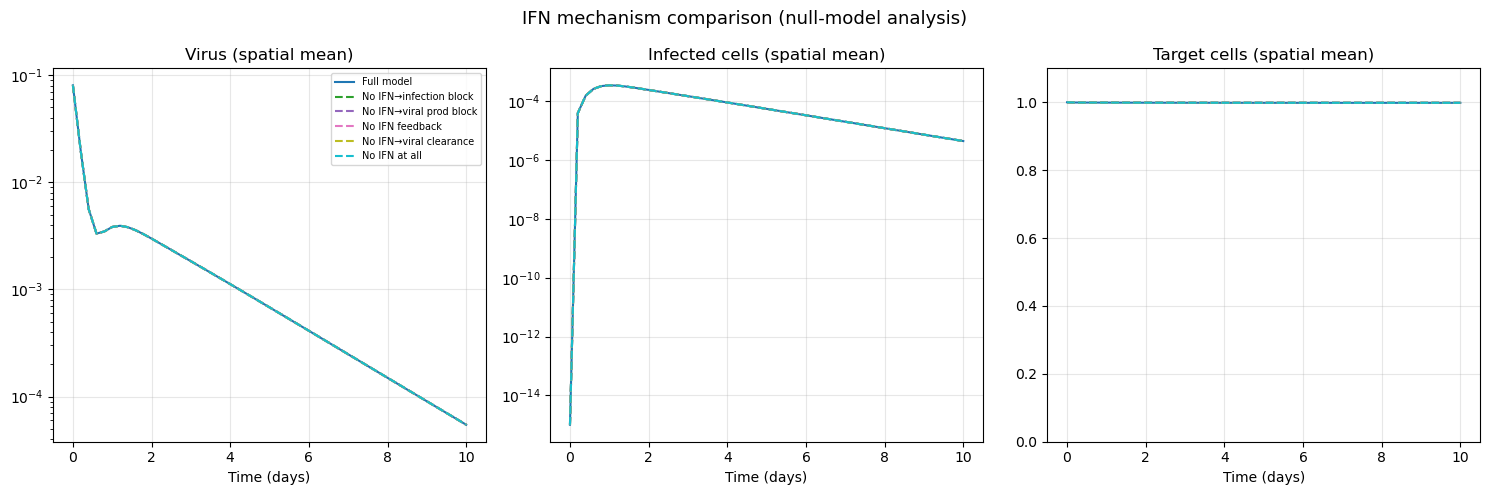

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors_sc = plt.cm.tab10(np.linspace(0, 1, len(scenarios)))

for (name, (t, Vm, Im, Tm)), c in zip(results.items(), colors_sc):
    ls = '-' if name == 'Full model' else '--'
    axes[0].semilogy(t, Vm + 1e-15, label=name, color=c, ls=ls)
    axes[1].semilogy(t, Im + 1e-15, label=name, color=c, ls=ls)
    axes[2].plot(t, Tm,             label=name, color=c, ls=ls)

axes[0].set_title('Virus (spatial mean)'); axes[0].set_xlabel('Time (days)')
axes[1].set_title('Infected cells (spatial mean)'); axes[1].set_xlabel('Time (days)')
axes[2].set_title('Target cells (spatial mean)'); axes[2].set_xlabel('Time (days)')
axes[2].set_ylim([0, 1.1])

for ax in axes:
    ax.grid(alpha=0.3)
axes[0].legend(fontsize=7, loc='upper right')

plt.suptitle('IFN mechanism comparison (null-model analysis)', fontsize=13)
plt.tight_layout()
# plt.savefig('mechanism_comparison.png', dpi=120)
plt.show()
# print('Saved → mechanism_comparison.png')

## 11. Summary Statistics

In [13]:
print(f'{'Scenario':<35} {'Peak V (mean)':>15} {'Peak I (mean)':>15} {'T remaining':>12}')
print('-'*80)
for name, (t, Vm, Im, Tm) in results.items():
    print(f'{name:<35} {Vm.max():>15.4g} {Im.max():>15.4g} {Tm[-1]:>12.4f}')

Scenario                              Peak V (mean)   Peak I (mean)  T remaining
--------------------------------------------------------------------------------
Full model                                  0.08056       0.0003528       0.9984
No IFN→infection block                      0.08056       0.0003528       0.9984
No IFN→viral prod block                     0.08056       0.0003528       0.9984
No IFN feedback                             0.08056       0.0003528       0.9984
No IFN→viral clearance                      0.08056       0.0003528       0.9984
No IFN at all                               0.08056       0.0003528       0.9984


## 12. Notes for ABM Comparison

When comparing this PDE model to your ABM:

| Aspect | PDE | ABM |
|--------|-----|-----|
| **Spatial coupling** | Continuous diffusion (∇²) | Discrete neighbourhood / diffusion grid |
| **Stochasticity** | Deterministic | Stochastic (births/deaths as events) |
| **Cell individuality** | Mean-field densities | Individual cell states |
| **IFN signalling** | Continuous F field | Per-cell or per-grid IFN |
| **Appropriate metric for comparison** | Spatial-mean time course; radial spread speed | Ensemble average over ABM runs |

**Suggested comparison workflow:**
1. Match initial conditions (inoculum size, cell density).
2. Compare spatial-mean V(t), I(t), T(t) curves.
3. Compare radial wavefront speed.
4. Run the null-mechanism scenarios on both models to check if individual IFN mechanisms have the same qualitative effect.
5. Scale noise in the ABM by varying grid resolution or cell count to approach the PDE limit.